In [231]:
# =========================================
# LIBRERÍAS BÁSICAS
# =========================================

import numpy as np
import pandas as pd

# =========================================
# VISUALIZACIÓN
# =========================================

import matplotlib.pyplot as plt
import seaborn as sns

# =========================================
# PREPROCESAMIENTO
# =========================================

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import RobustScaler
from sklearn.pipeline import Pipeline

# =========================================
# MODEL SELECTION
# =========================================

from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    KFold,
    GridSearchCV,
    RandomizedSearchCV
)

# =========================================
# MÉTRICAS
# =========================================

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

# =========================================
# MODELOS
# =========================================

from sklearn.dummy import DummyRegressor

from sklearn.linear_model import (
    LinearRegression,
    Ridge,
    Lasso,
    ElasticNet
)

from sklearn.tree import DecisionTreeRegressor

from sklearn.ensemble import RandomForestRegressor

from sklearn.neighbors import KNeighborsRegressor

from sklearn.svm import SVR

# =========================================
# UTILIDADES
# =========================================

import warnings
warnings.filterwarnings("ignore")

import joblib

In [232]:
df = pd.read_excel('../train_competicion.xlsx')
df

,V0,V1,V2,V3,V4,V5,V6,V7,V8,V9,deseada
0,98.61,4.068343,NaN,8.665653,-1.092046,2.891,1.442,NaN,0.0,0.512300,9.140
1,20.31,3.376529,0.000000,-0.020346,0.717691,1.401,2.073,1.0,1.0,0.411375,0.704
2,45.82,3.946366,0.000000,6.719171,0.433881,2.048,NaN,1.0,0.0,0.829723,3.615
3,91.49,4.773866,2.236068,-0.035611,0.693325,1.868,1.621,5.0,0.0,0.337303,1.983
4,0.00,0.000000,NaN,99.510312,-1.081747,2.018,0.461,0.0,NaN,0.727529,5.600
...,...,...,...,...,...,...,...,...,...,...,...
431,20.23,3.776959,1.000000,112.888678,-0.158617,NaN,1.229,0.0,0.0,0.182672,6.360
432,9.23,2.484907,0.000000,0.512000,-2.761062,NaN,2.003,0.0,0.0,0.444115,1.730
433,0.00,0.000000,0.000000,86.116663,1.896738,NaN,0.723,0.0,NaN,0.535152,5.626
434,79.63,4.367864,1.414214,2.331474,1.628346,NaN,1.126,5.0,0.0,0.092500,5.054


436 muestras (buen número) y 10 variables que pueden predecir "deseada" (Y)

In [233]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 436 entries, 0 to 435
Data columns (total 11 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   V0       436 non-null    float64
 1   V1       365 non-null    float64
 2   V2       373 non-null    float64
 3   V3       368 non-null    float64
 4   V4       436 non-null    float64
 5   V5       373 non-null    float64
 6   V6       366 non-null    float64
 7   V7       376 non-null    float64
 8   V8       368 non-null    float64
 9   V9       436 non-null    float64
 10  deseada  436 non-null    float64
dtypes: float64(11)
memory usage: 37.6 KB


Todos son float (números decimales), están bien "etiquetados"

In [234]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
V0,436.0,50.893945,48.915139,0.000000,17.070000,41.350000,74.570000,347.320000
V1,365.0,3.270661,1.754086,0.000000,2.697528,3.813594,4.448271,6.350802
V2,373.0,0.639217,0.766561,0.000000,0.000000,0.000000,1.000000,4.242641
V3,368.0,34.930814,62.371088,-2.948815,1.913777,11.681740,42.346097,765.558650
V4,436.0,0.045051,1.056036,-2.761062,-0.656870,0.068302,0.804713,2.562528
V5,373.0,2.528764,0.849422,1.000000,1.975000,2.334000,3.001000,6.439000
V6,366.0,1.030762,0.406899,0.281000,0.726000,0.995500,1.250000,2.500000
V7,376.0,1.061170,1.481974,0.000000,0.000000,1.000000,2.000000,11.000000
V8,368.0,0.372283,0.873462,0.000000,0.000000,0.000000,1.000000,11.000000
V9,436.0,0.470497,0.286910,0.000187,0.222742,0.458547,0.724238,0.997623


vemos que algunas variables tienen números negativos (V3 y V4), que no hay demasiada desviación (dónde más en V0 y V3) pero cmo no sabemos nada más funcional tampoco podemos sacar conclusiones tipo "es imposible que V3 tenga valores negativos" y así


In [235]:
df.isnull().sum()

V0          0
V1         71
V2         63
V3         68
V4          0
V5         63
V6         70
V7         60
V8         68
V9          0
deseada     0
dtype: int64

In [236]:
df.isnull().sum() / len(df)

V0         0.000000
V1         0.162844
V2         0.144495
V3         0.155963
V4         0.000000
V5         0.144495
V6         0.160550
V7         0.137615
V8         0.155963
V9         0.000000
deseada    0.000000
dtype: float64

Vemos que los nulos, sin duda, será un "problema a tratar"

# Separación de datasets: 

* df_original -> raw, tal como se nos da
* df_dropna -> borrado TODOS los nulos
* df_mean -> imputación de media en los nulos -> puede que no sea la mejor opvión por los outliers, mejor mediana
* df_median -> imputación de mediana en los nulos
* df_imputer -> KNNImputer con grupos similares (k=?)

# EDA

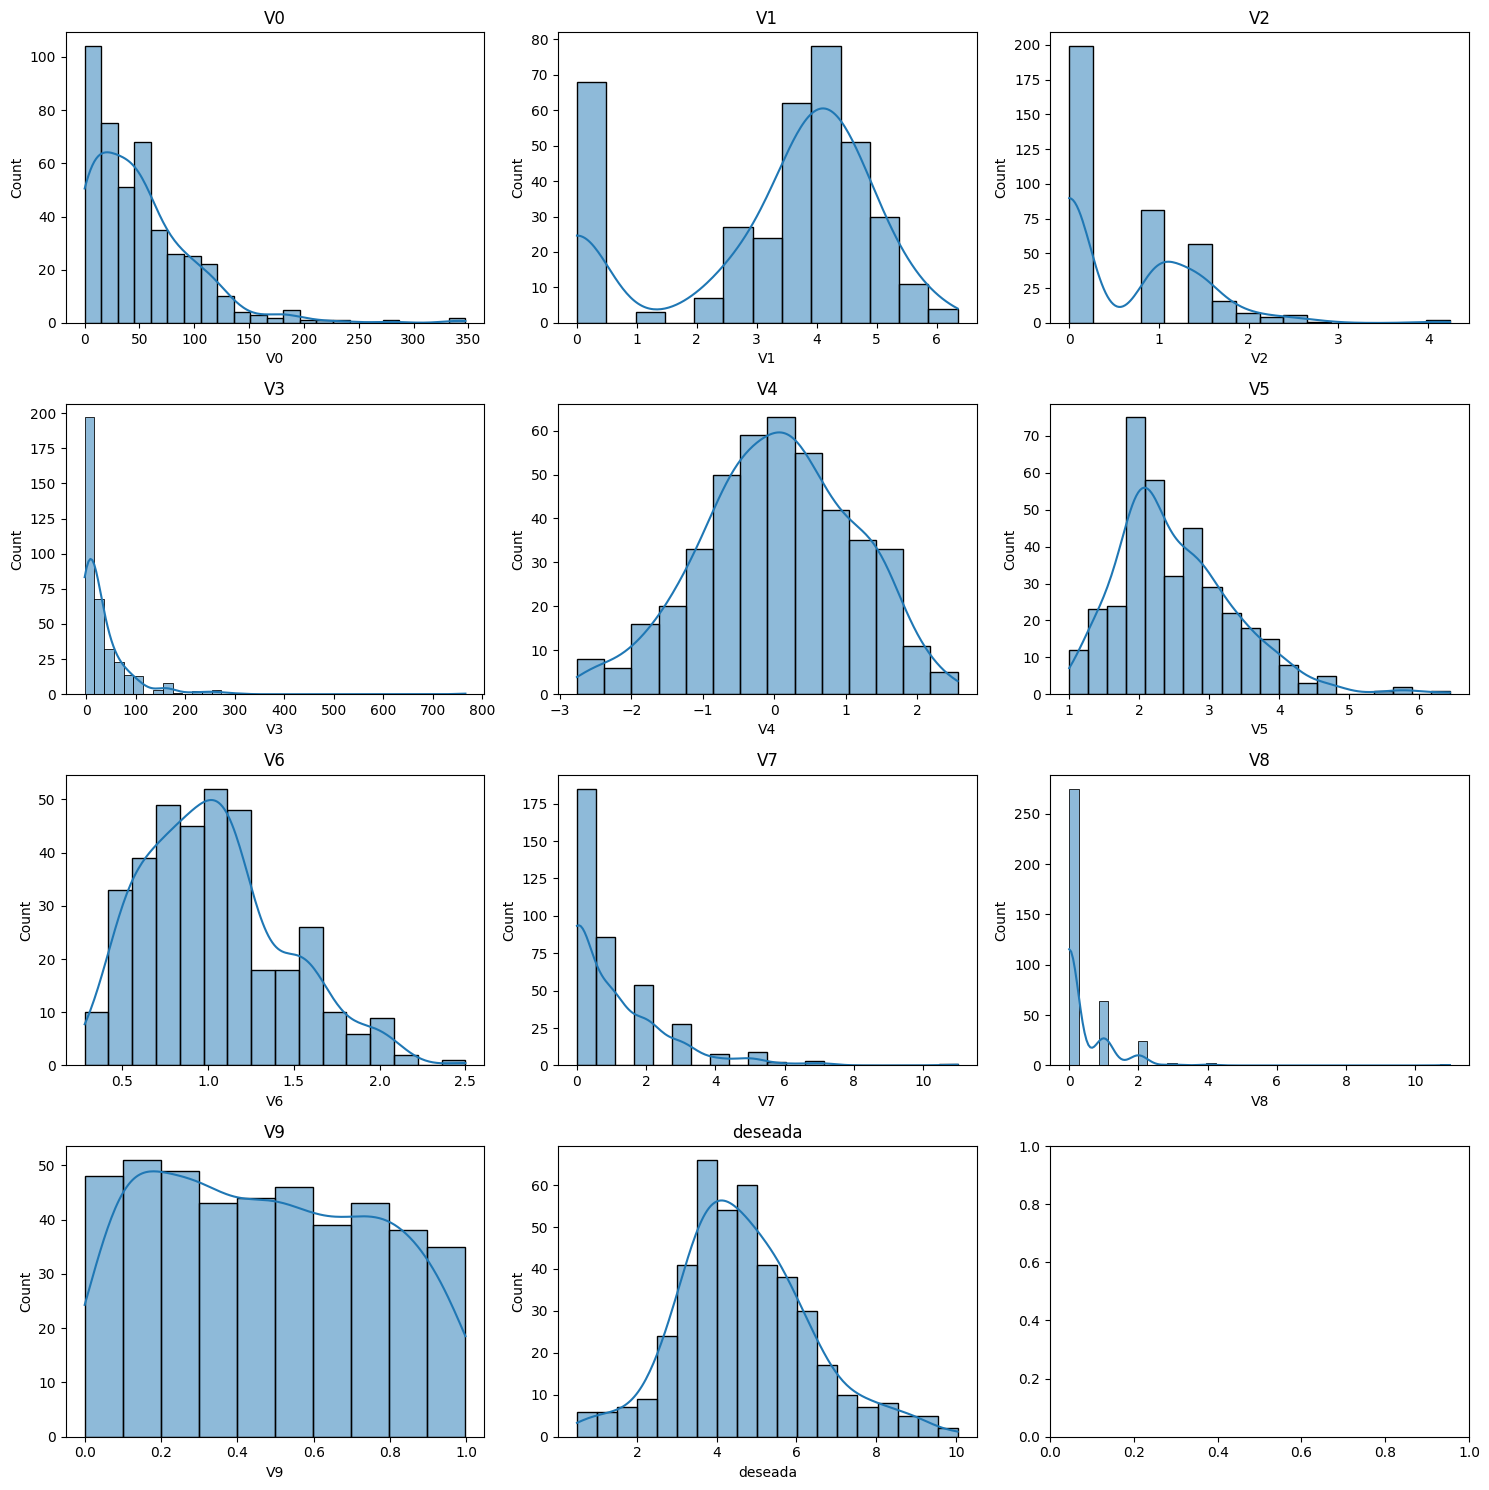

In [237]:
## Histogramas (solo muestra los valores con dato, los nulos los deja fuera)

fig, axes = plt.subplots(4, 3, figsize=(15, 15))

axes = axes.flatten()

for i, col in enumerate(df.columns):

    sns.histplot(
        df[col],
        kde=True,
        ax=axes[i]
    )

    axes[i].set_title(col)

plt.tight_layout()

plt.show()

¿qué vemos?

* Colas pesadas (posibles transformaciones log) -> V0, 3, 7 y 8

Nota: cuando hacemos este tipo de análisis los NaN se quedan fuera, es decir, todos esos valores interpretados como 0 son 0 reales, los NaN se quedan fuera de interpretaciones. 

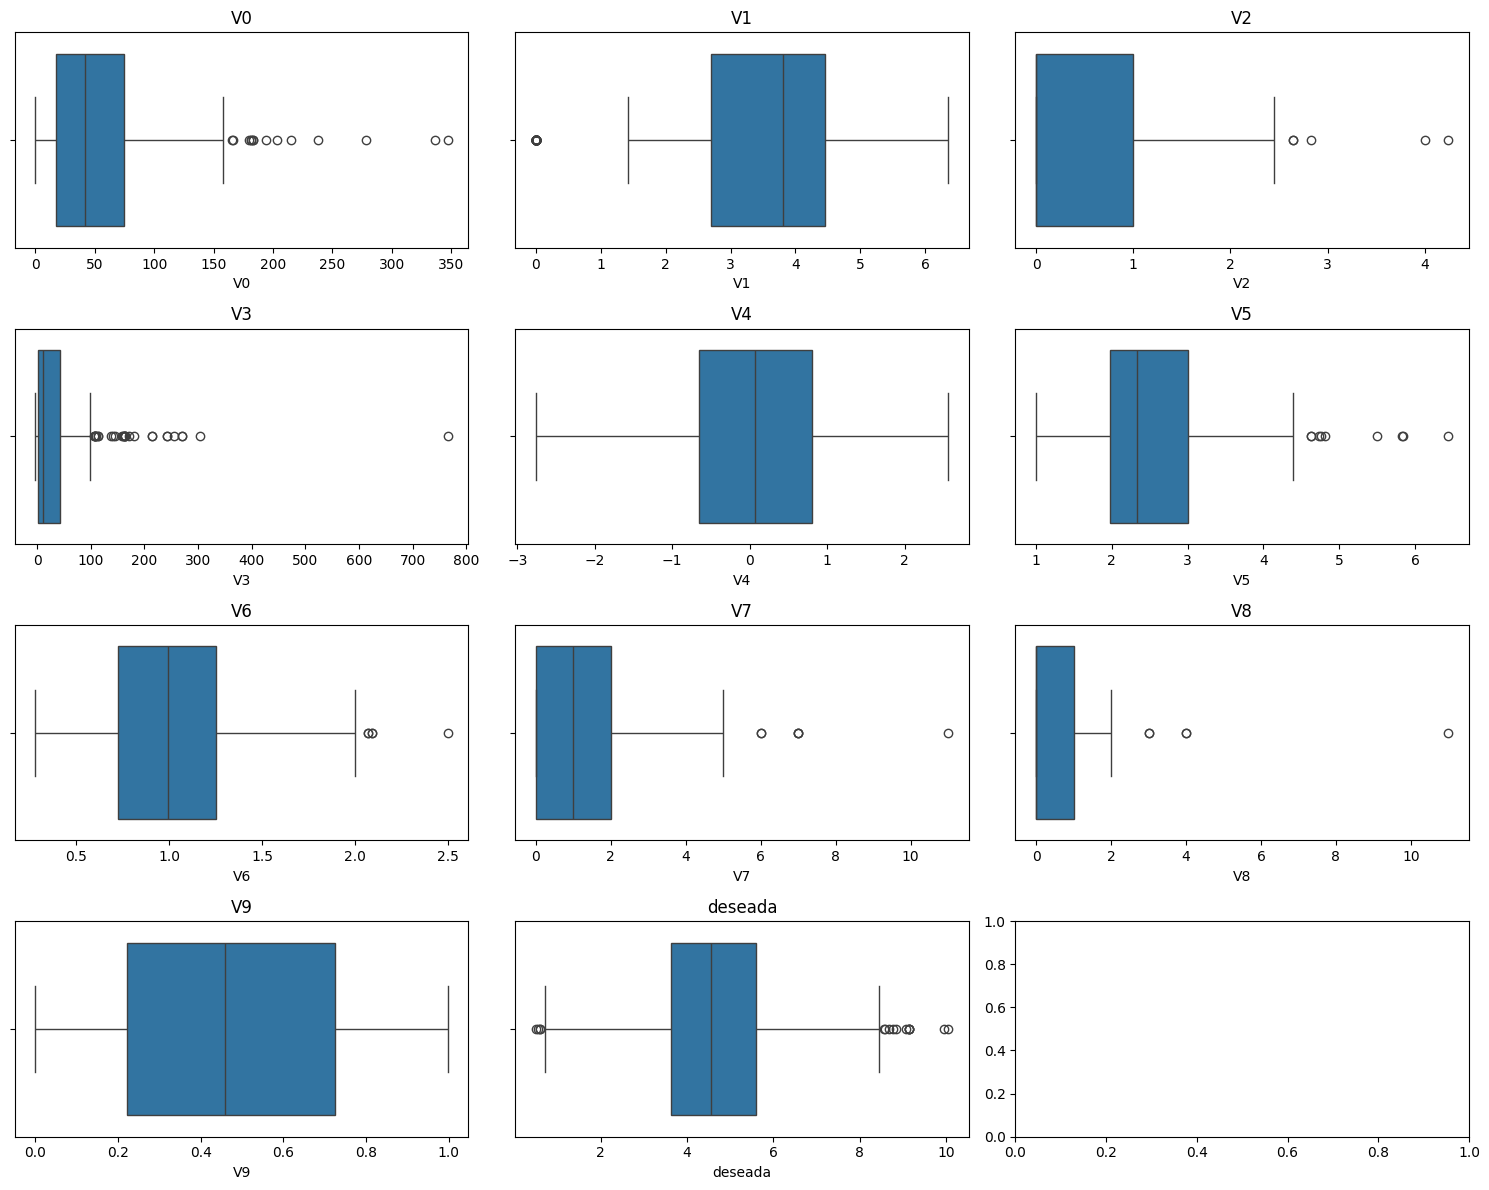

In [238]:
## Boxplot

fig, axes = plt.subplots(4, 3, figsize=(15, 12))

axes = axes.flatten()

for i, col in enumerate(df.columns):

    sns.boxplot(
        x=df[col],
        ax=axes[i]
    )

    axes[i].set_title(col)

plt.tight_layout()

plt.show()

¿qué vemos?

* Outliers especialmente en: 3 y 0
* Ouliers "moderados": 5,6,7,8. Incluso la target

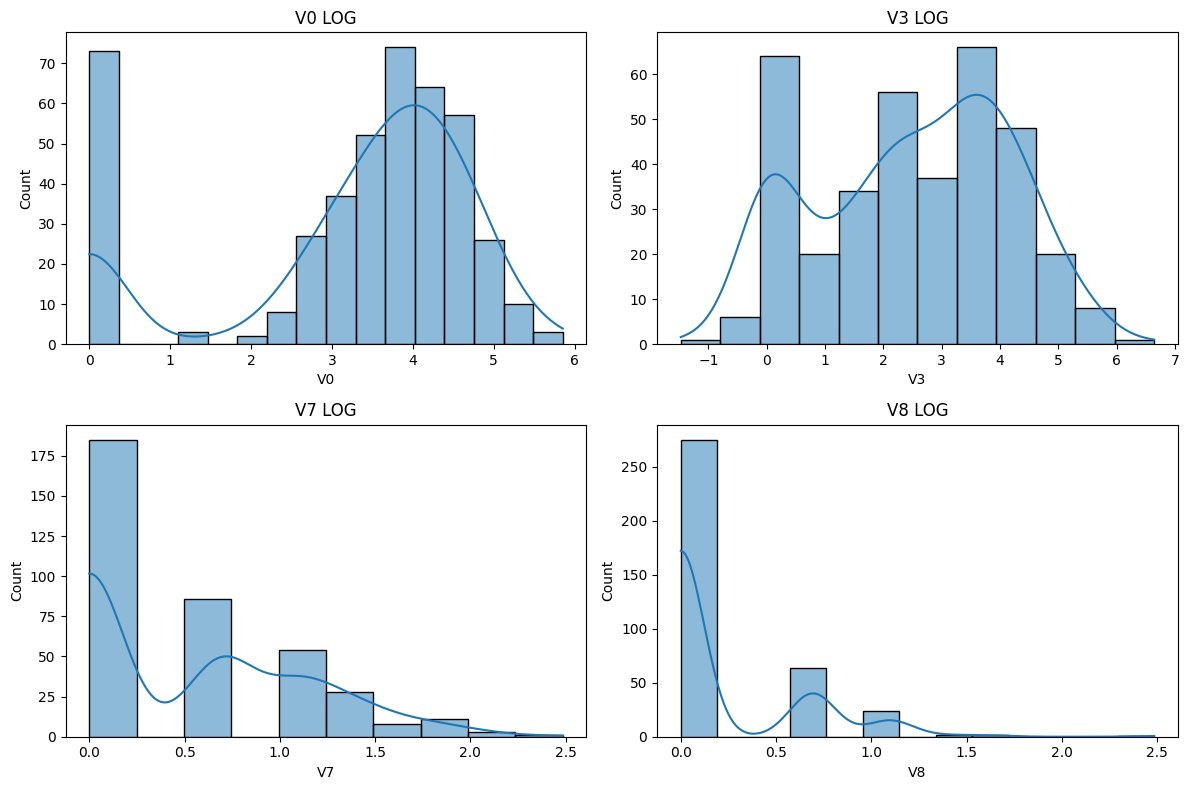

In [239]:
### Creo versiones LOG (sin reemplazar):

# Copio df "log" donde aplico el log
df_log = df.copy()

# Creo bucle con las variables observadas con cola pesada
# y aplico el log:

cols_log = ['V0', 'V3', 'V7', 'V8']

for col in cols_log:
    
    df_log[col] = np.log1p(df_log[col])

# Y pinto el histograma para comprobar si las distribuciones se vuelven más "normales":
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes = axes.flatten()

for i, col in enumerate(cols_log):

    sns.histplot(
        df_log[col],
        kde=True,
        ax=axes[i]
    )

    axes[i].set_title(f'{col} LOG')

plt.tight_layout()

plt.show()

Conclusiones:

Aplico Log en V0 y V3

In [240]:
# Creo BKP para tener siempre el original (raw)
df_original = df.copy()

In [241]:
# creo las columnas con la aplicación de log a las dos variables que hemos visto que mejoran:
df['V0_log'] = np.log1p(df['V0'])
df['V3_log'] = np.log1p(df['V3'])

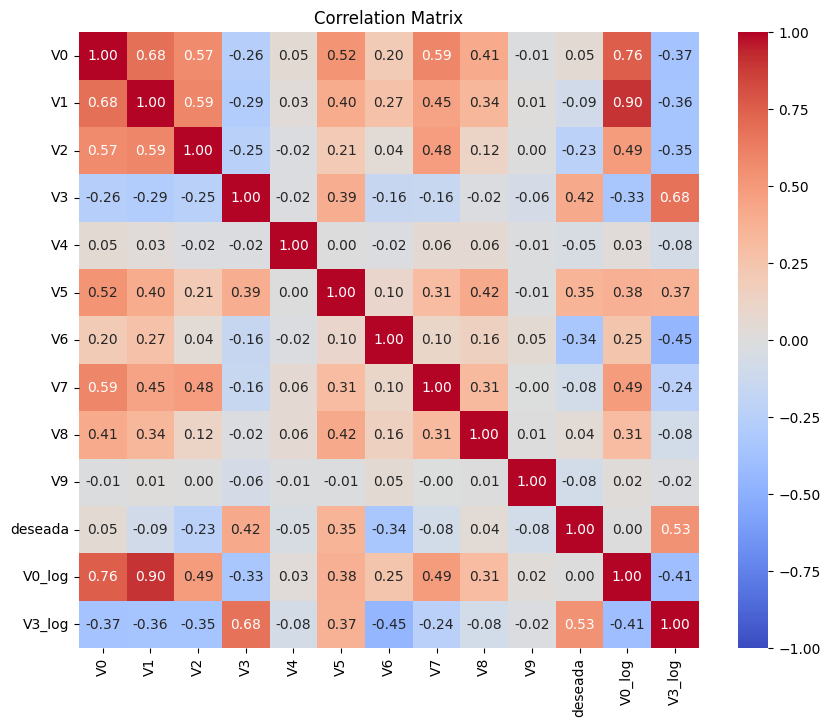

In [242]:
## Correlaciones

plt.figure(figsize=(10, 8))

sns.heatmap(
    df.corr(),
    annot=True,
    fmt=".2f",
    cmap='coolwarm',
    center=0,
    vmin= -1,
    vmax = 1
)

plt.title('Correlation Matrix')

plt.show()

In [243]:
# para eliminar ruido, vemos corr solo con el target:

corr_target = (
    df.corr()['deseada']
    .sort_values(key=abs, ascending=False)
)

corr_target

deseada    1.000000
V3_log     0.533039
V3         0.418041
V5         0.354746
V6        -0.337615
V2        -0.226891
V1        -0.091165
V7        -0.080410
V9        -0.078162
V0         0.047942
V4        -0.045949
V8         0.042958
V0_log     0.004720
Name: deseada, dtype: float64

Conclusiones:

Variables correlacionadas positivamente: V3_log, V5
Variables correlacionadas negativamente: V6, V2

La que sí parece que no aporte es V0_log, podemos eliminarla. 

In [244]:
# eliminamos V0_log ya que no aporta nada:
df.drop(columns='V0_log', inplace=True)

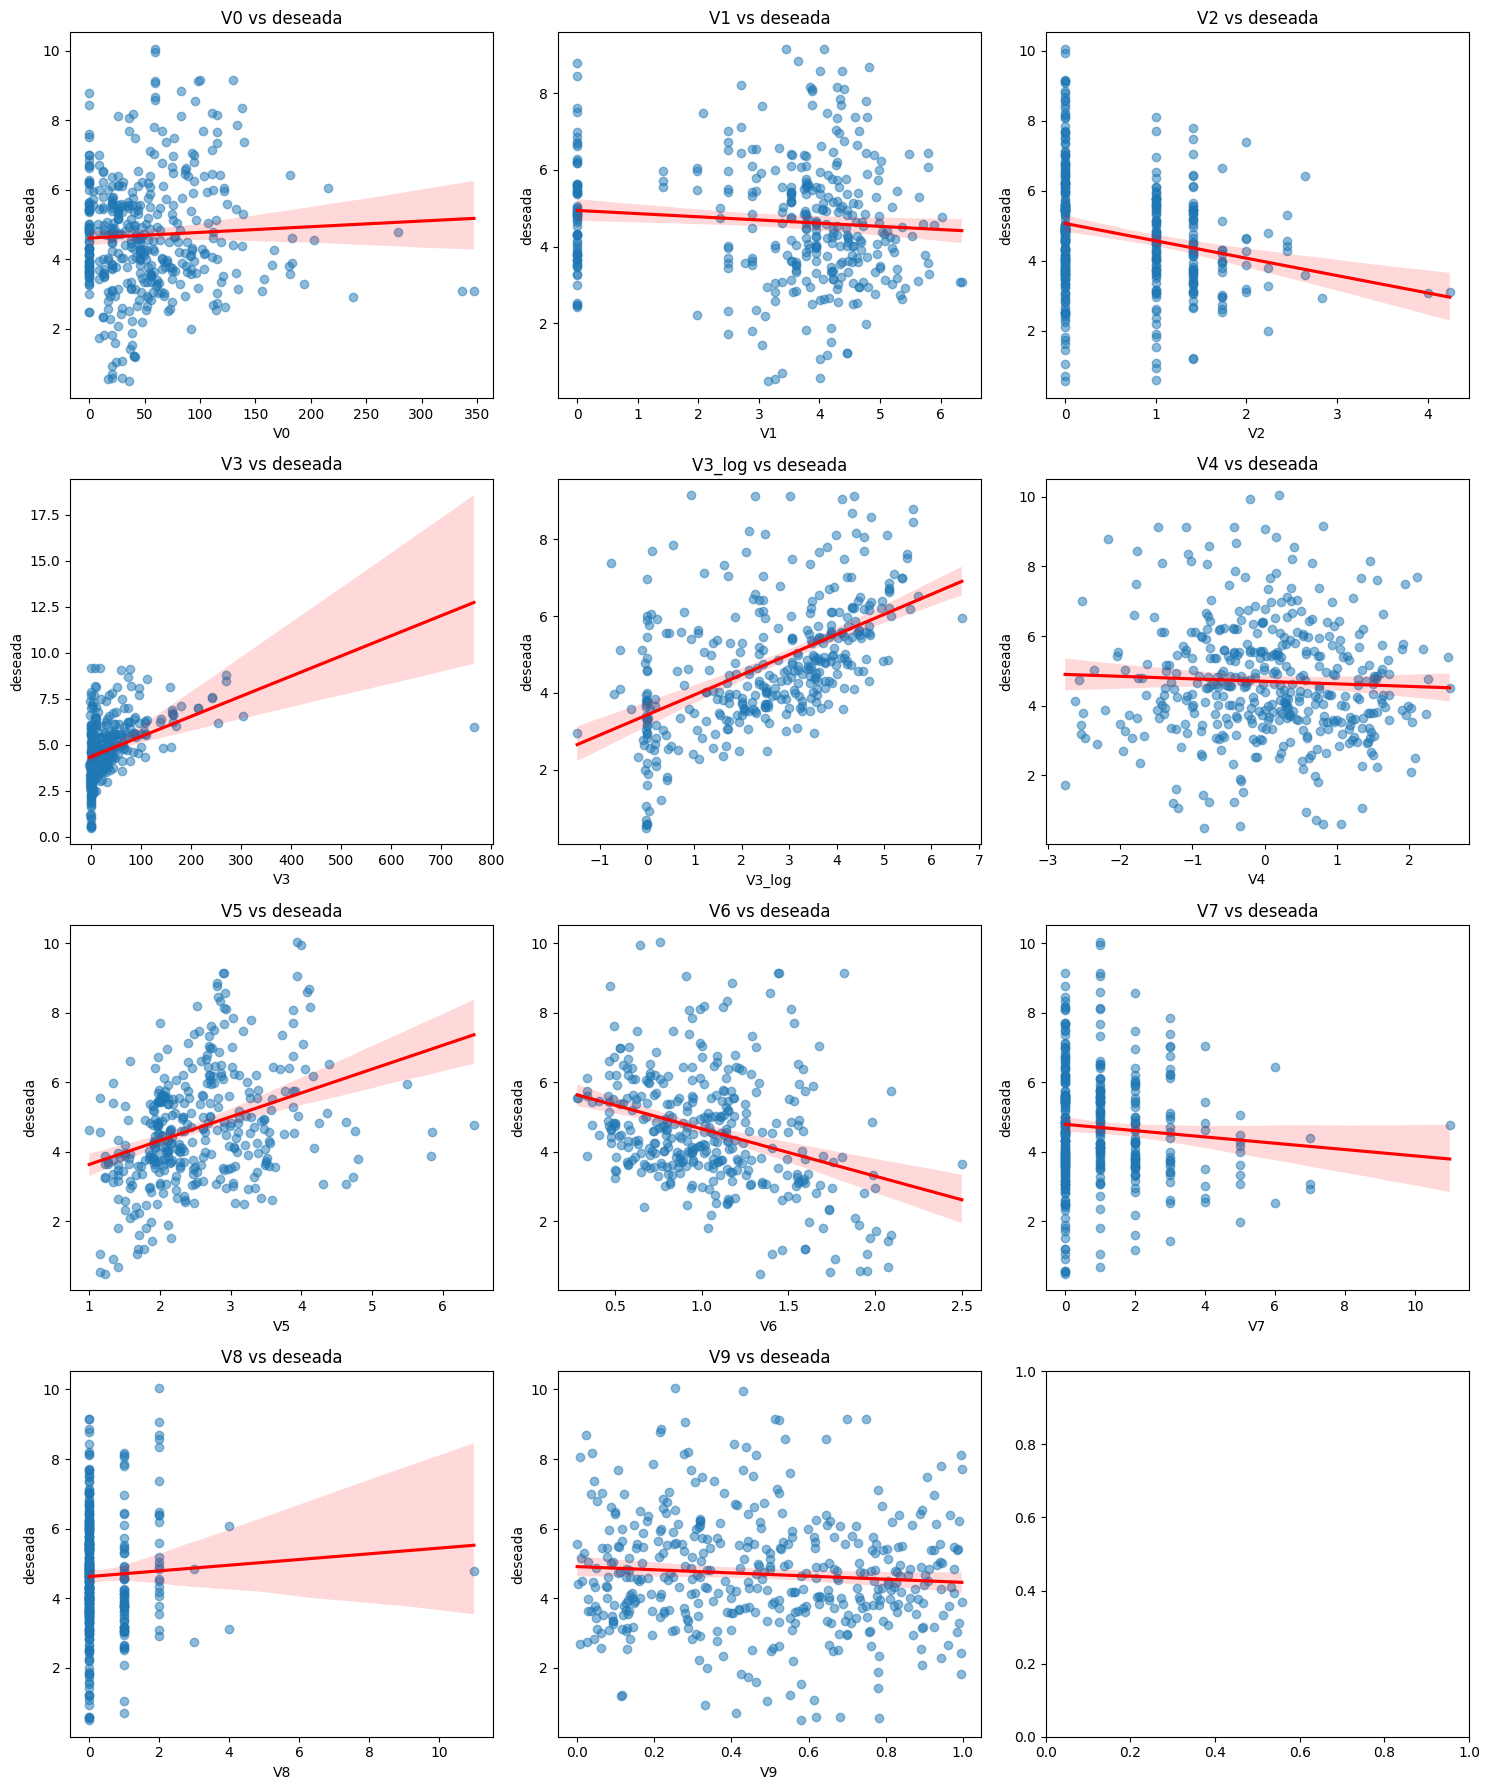

In [245]:
# Scatterplots con target

features = [
    'V0', 'V1', 'V2', 'V3', 'V3_log',
    'V4', 'V5', 'V6', 'V7', 'V8', 'V9'
]

fig, axes = plt.subplots(4, 3, figsize=(15, 18))

axes = axes.flatten()

for i, col in enumerate(features):

    sns.regplot(
        data=df,
        x=col,
        y='deseada',
        scatter_kws={'alpha': 0.5},
        line_kws={'color': 'red'},
        ax=axes[i]
    )

    axes[i].set_title(f'{col} vs deseada')

plt.tight_layout()

plt.show()

Conclusiones:

Con esto podemos ver relaciones lineales con: V3_log, V5, V6 y algo con V2

El resto no deja clara una relaciones PERO ojo porque modelos como: árboles, random forest o SVR puedes capturar no linealidad, así que no las sacamos del dataframe

Además, como ya veniamos observando, V2, V7 y V8 parecen discretas.

# Primer dataset "modelo" (nulos = mediana)

Implicacines
1. Imputamos los nulos con la mediana ya que hemos visto que la media podría desvistualizar los datos por los ouliers. Nota: más adelante podemos plantearnos técnicas más sofisticadas como K-Means.
2. Transformaba V3 a log y nos quedamos con V3_log

NOTA IMPORTANTE: lo hacemos sobre el original porque ahora mismo arrastramos nulos en V3_log dado que lo hemos aplicado a partir de V· (valores nulos)

In [246]:
df_mediana = df_original.copy()

df_mediana = df_mediana.fillna(df_mediana.median())

# tenemos que crear un shift (sumamos 1 porque V3 tiene valores negativos y esto nos da problemas con log)
df_mediana['V3_shift'] = (df_mediana['V3']- df_mediana['V3'].min() + 1)

# ahora ya podemos hacer el log de V3
df_mediana['V3_log'] = np.log1p(df_mediana['V3_shift'])

# y borro las columnas "auxiliares" para dejar limpio el dataset
df_mediana = df_mediana.drop(columns=['V3', 'V3_shift'])

df_mediana.isnull().sum()

V0         0
V1         0
V2         0
V4         0
V5         0
V6         0
V7         0
V8         0
V9         0
deseada    0
V3_log     0
dtype: int64

In [247]:
df_mediana.shape

(436, 11)

In [248]:
df_mediana.columns

Index(['V0', 'V1', 'V2', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'deseada',
       'V3_log'],
      dtype='object')

In [249]:
df_mediana.describe().T

,count,mean,std,min,25%,50%,75%,max
V0,436.0,50.893945,48.915139,0.000000,17.070000,41.350000,74.570000,347.320000
V1,436.0,3.359074,1.617066,0.000000,3.016425,3.813594,4.306676,6.350802
V2,436.0,0.546853,0.743733,0.000000,0.000000,0.000000,1.000000,4.242641
V4,436.0,0.045051,1.056036,-2.761062,-0.656870,0.068302,0.804713,2.562528
V5,436.0,2.500622,0.788494,1.000000,1.995000,2.334000,2.893750,6.439000
V6,436.0,1.025101,0.372951,0.281000,0.784000,0.995500,1.174250,2.500000
V7,436.0,1.052752,1.376140,0.000000,0.000000,1.000000,1.000000,11.000000
V8,436.0,0.314220,0.813608,0.000000,0.000000,0.000000,0.000000,11.000000
V9,436.0,0.470497,0.286910,0.000187,0.222742,0.458547,0.724238,0.997623
deseada,436.0,4.694101,1.662778,0.495000,3.627250,4.560000,5.600000,10.047000


# MODELOS

In [250]:
# Split
X = df_mediana.drop(columns='deseada')
y = df_mediana['deseada']


X_train, X_test, y_train, y_test = train_test_split(
                                                    X,
                                                    y,
                                                    test_size=0.20,
                                                    random_state=42,
                                                    shuffle=True
                                                )

print(X_train.shape)
print(X_test.shape)

(348, 10)
(88, 10)


## Baseline -> Dummy

In [251]:
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_squared_error

In [252]:

dummy = DummyRegressor(strategy='mean')

dummy.fit(X_train, y_train)

y_pred_dummy = dummy.predict(X_test)

mse_dummy = mean_squared_error(y_test, y_pred_dummy)

print("Baseline MSE:", mse_dummy)

Baseline MSE: 3.1677915724786514


## Linear Regression

In [253]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

In [254]:
pipe_lr = Pipeline([
                        ('scaler', StandardScaler()),
                        ('model', LinearRegression())
                ])

pipe_lr.fit(X_train, y_train)

y_pred_lr = pipe_lr.predict(X_test)

In [255]:
mse_lr = mean_squared_error(y_test, y_pred_lr)

print("Linear Regression MSE:", mse_lr)

Linear Regression MSE: 2.1386890483520307


In [256]:
# Comparación modelos:

print("Baseline MSE:", mse_dummy)
print("Linear Regression MSE:", mse_lr)

Baseline MSE: 3.1677915724786514
Linear Regression MSE: 2.1386890483520307


## Cross Validation

In [257]:
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import KFold


In [258]:
# esto lo usaré para todos, es una manera de asegurarme que esos split de dentro tienen shuffle = True (proporción de "deseada")
kf = KFold(
            n_splits=5,
            shuffle=True,
            random_state=42
        )

In [259]:
cv_scores_lr = cross_val_score(
                                pipe_lr,
                                X_train,
                                y_train,
                                cv=kf,
                                scoring='neg_mean_squared_error'
                            )

In [260]:
cv_mse_lr = -cv_scores_lr.mean()

print("Linear Regression MSE (CV):", cv_mse_lr)

Linear Regression MSE (CV): 1.8278900446778532


In [261]:
print("Baseline MSE:", mse_dummy)
print("Linear Regression MSE:", mse_lr)
print("Linear Regression MSE (CV):", cv_mse_lr)

Baseline MSE: 3.1677915724786514
Linear Regression MSE: 2.1386890483520307
Linear Regression MSE (CV): 1.8278900446778532


Conclusiones: estamos reduciendo el MSE, tiene buena pinta 

## REGULARIZACIÓN: Ridge

In [262]:
from sklearn.linear_model import Ridge

In [263]:
# defino
pipe_ridge = Pipeline([
                        ('scaler', StandardScaler()),
                        ('model', Ridge(alpha=1.0))
                    ])

# entreno
pipe_ridge.fit(X_train, y_train)

# predigo
y_pred_ridge = pipe_ridge.predict(X_test)

In [264]:
mse_ridge = mean_squared_error(y_test, y_pred_ridge)

print("Ridge MSE:", mse_ridge)

Ridge MSE: 2.1372444387032496


In [265]:
cv_scores_ridge = cross_val_score(  
                                    pipe_ridge,
                                    X_train,
                                    y_train,
                                    cv=kf,
                                    scoring='neg_mean_squared_error'
                                )

In [266]:
cv_mse_ridge = -cv_scores_ridge.mean()

print("Ridge MSE (CV):", cv_mse_ridge)

Ridge MSE (CV): 1.8264160972593717


In [267]:
# Comparación hasta ahora:

In [268]:
print("Baseline:", mse_dummy)
print("Linear Regression:", mse_lr)
print("Ridge:", mse_ridge)

Baseline: 3.1677915724786514
Linear Regression: 2.1386890483520307
Ridge: 2.1372444387032496


## REGULARIZACIÓN: Lasso

In [269]:
from sklearn.linear_model import Lasso

In [270]:
# defino
pipe_lasso = Pipeline([
                        ('scaler', StandardScaler()),
                        ('model', Lasso(alpha=0.01))
                    ])

# entreno
pipe_lasso.fit(X_train, y_train)

# predigo
y_pred_lasso = pipe_lasso.predict(X_test)

In [271]:
mse_lasso = mean_squared_error(y_test, y_pred_lasso)

print("Lasso MSE:", mse_lasso)

Lasso MSE: 2.122270753632836


In [272]:
cv_scores_lasso = cross_val_score(
                                    pipe_lasso,
                                    X_train,
                                    y_train,
                                    cv=kf,
                                    scoring='neg_mean_squared_error'
                                )

In [273]:
cv_mse_lasso = -cv_scores_lasso.mean()

print("Lasso MSE (CV):", cv_mse_lasso)

Lasso MSE (CV): 1.8186783688687158


## REGULARIZACIÓN: ElasticNet

In [274]:
from sklearn.linear_model import ElasticNet

In [275]:
# defino
pipe_elastic = Pipeline([
                            ('scaler', StandardScaler()),
                            ('model', ElasticNet(
                                                    alpha=0.01,
                                                    l1_ratio=0.5
                                                )
                            )
                        ])

# entreno
pipe_elastic.fit(X_train, y_train)

# predigo
y_pred_elastic = pipe_elastic.predict(X_test)

In [276]:
mse_elastic = mean_squared_error(y_test, y_pred_elastic)

print("ElasticNet MSE:", mse_elastic)

ElasticNet MSE: 2.1279688309941602


In [277]:
cv_scores_elastic = cross_val_score(
                                    pipe_elastic,
                                    X_train,
                                    y_train,
                                    cv=kf,
                                    scoring='neg_mean_squared_error'
                                )

In [278]:
cv_mse_elastic = -cv_scores_elastic.mean()

print("ElasticNet MSE (CV):", cv_mse_elastic)

ElasticNet MSE (CV): 1.820991442088379


Hasta aquí modelos que tienen que ver con relaciones puramente lineales. Hago una pequeña recopilicaión.

In [279]:
results = pd.DataFrame({

    'Modelo': [

        'Baseline',
        'Linear Regression',
        'Ridge',
        'Lasso',
        'ElasticNet'
    ],

    'MSE': [

        mse_dummy,
        mse_lr,
        mse_ridge,
        mse_lasso,
        mse_elastic
    ],

    'MSE_CV': [

        np.nan,
        cv_mse_lr,
        cv_mse_ridge,
        cv_mse_lasso,
        cv_mse_elastic
    ]
})

In [280]:
results.sort_values(by='MSE_CV',ascending=True)

,Modelo,MSE,MSE_CV
3,Lasso,2.122271,1.818678
4,ElasticNet,2.127969,1.820991
2,Ridge,2.137244,1.826416
1,Linear Regression,2.138689,1.827890
0,Baseline,3.167792,NaN


In [281]:
results.sort_values(by='MSE',ascending=True)

,Modelo,MSE,MSE_CV
3,Lasso,2.122271,1.818678
4,ElasticNet,2.127969,1.820991
2,Ridge,2.137244,1.826416
1,Linear Regression,2.138689,1.827890
0,Baseline,3.167792,NaN


## SVR 

In [282]:
from sklearn.svm import SVR

In [283]:
# defino
pipe_svr = Pipeline([
                    ('scaler', StandardScaler()),
                    ('model', SVR(
                                    kernel='rbf',
                                    C=1.0,
                                    epsilon=0.1
                                )
                    )
                ])

# entreno
pipe_svr.fit(X_train, y_train)

# predigo
y_pred_svr = pipe_svr.predict(X_test)

In [284]:
mse_svr = mean_squared_error(y_test, y_pred_svr)

print("SVR MSE:", mse_svr)

SVR MSE: 1.7187361860215034


In [285]:
cv_scores_svr = cross_val_score(
                                pipe_svr,
                                X_train,
                                y_train,
                                cv=kf,
                                scoring='neg_mean_squared_error',
                                n_jobs=-1
                            )

In [286]:
cv_mse_svr = -cv_scores_svr.mean()

print("SVR MSE (CV):", cv_mse_svr)

SVR MSE (CV): 1.6019904009204295


## RandomForest

In [287]:
from sklearn.ensemble import RandomForestRegressor

In [288]:
# defino (de momento sencillo, sin GridSearch)
rf = RandomForestRegressor(
                            n_estimators=200,
                            max_depth=None,
                            random_state=42
                        )

# entreno
rf.fit(X_train, y_train)

# predigo
y_pred_rf = rf.predict(X_test)



In [289]:

mse_rf = mean_squared_error(y_test, y_pred_rf)
print("Random Forest MSE:", mse_rf)

Random Forest MSE: 1.3930750848133522


In [290]:
# comprbación CV

cv_scores_rf = cross_val_score(
                                rf,
                                X_train,
                                y_train,
                                cv=kf,
                                scoring='neg_mean_squared_error',
                                n_jobs=-1
                            )

cv_mse_rf = -cv_scores_rf.mean()

print("Random Forest MSE (CV):", cv_mse_rf)

Random Forest MSE (CV): 1.6816355216489796


# GradientBoostingRegressor

In [291]:
from sklearn.ensemble import GradientBoostingRegressor

In [292]:
# defino (de momento "a ojo" los hiperparámetros)
gbr = GradientBoostingRegressor(
                                n_estimators=200,
                                learning_rate=0.05,
                                max_depth=3,
                                random_state=42
                            )

# entreno
gbr.fit(X_train, y_train)

# predigo
y_pred_gbr = gbr.predict(X_test)

In [293]:
mse_gbr = mean_squared_error(y_test, y_pred_gbr)

print("GBR MSE:", mse_gbr)

GBR MSE: 1.4347724790221505


In [294]:
cv_scores_gbr = cross_val_score(
                                gbr,
                                X_train,
                                y_train,
                                cv=kf,
                                scoring='neg_mean_squared_error',
                                n_jobs=-1
                            )

cv_mse_gbr = -cv_scores_gbr.mean()

print("GBR MSE (CV):", cv_mse_gbr)

GBR MSE (CV): 1.5442499901996811


# XGBoost

In [295]:
from xgboost import XGBRegressor

In [296]:
# defino (de momento "a ojo" los hiperparámetros)
xgb = XGBRegressor(
                    n_estimators=300,
                    learning_rate=0.05,
                    max_depth=3,
                    random_state=42
                )

# entreno
xgb.fit(X_train, y_train)

# predigo
y_pred_xgb = xgb.predict(X_test)

In [297]:
mse_xgb = mean_squared_error(y_test, y_pred_xgb)

print("XGB MSE:", mse_xgb)

XGB MSE: 1.4406042815230273


In [298]:
cv_scores_xgb = cross_val_score(
                                xgb,
                                X_train,
                                y_train,
                                cv=kf,
                                scoring='neg_mean_squared_error',
                                n_jobs=-1
                            )

cv_mse_xgb = -cv_scores_xgb.mean()

print("XGB MSE (CV):", cv_mse_xgb)

XGB MSE (CV): 1.59513690526842


In [299]:
# añado a la tabla de results los nuevos modelos "no lineales": SVR, RF, GBR, XGB

update_results = pd.DataFrame({
                                'Modelo': [
                                            'SVR',
                                            'RandomForest',
                                            'GradientBoosting',
                                            'XGBoost'
                                        ],

                                'MSE': [
                                            mse_svr,
                                            mse_rf,
                                            mse_gbr,
                                            mse_xgb
                                        ],

                                'MSE_CV': [
                                            cv_mse_svr,
                                            cv_mse_rf,
                                            cv_mse_gbr,
                                            cv_mse_xgb
                                        ]
                            }) 

# concateno 
results = pd.concat(
                    [results, update_results],
                    ignore_index=True
                )  

# ordeno para que se actualize el orden   
results = results.sort_values(by='MSE_CV',ascending=True)

results 

,Modelo,MSE,MSE_CV
7,GradientBoosting,1.434772,1.544250
8,XGBoost,1.440604,1.595137
5,SVR,1.718736,1.601990
6,RandomForest,1.393075,1.681636
3,Lasso,2.122271,1.818678
4,ElasticNet,2.127969,1.820991
2,Ridge,2.137244,1.826416
1,Linear Regression,2.138689,1.827890
0,Baseline,3.167792,NaN


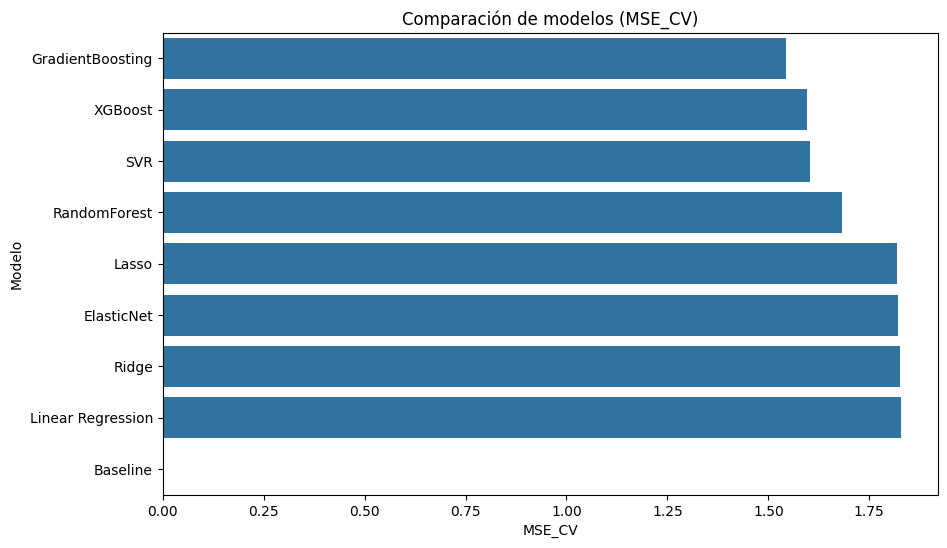

In [300]:
# Visualmente

plt.figure(figsize=(10, 6))

sns.barplot(
            data=results,
            x='MSE_CV',
            y='Modelo'
        )

plt.title('Comparación de modelos (MSE_CV)')

plt.show()

In [301]:
results.sort_values(by='MSE',ascending=True)

,Modelo,MSE,MSE_CV
6,RandomForest,1.393075,1.681636
7,GradientBoosting,1.434772,1.544250
8,XGBoost,1.440604,1.595137
5,SVR,1.718736,1.601990
3,Lasso,2.122271,1.818678
4,ElasticNet,2.127969,1.820991
2,Ridge,2.137244,1.826416
1,Linear Regression,2.138689,1.827890
0,Baseline,3.167792,NaN


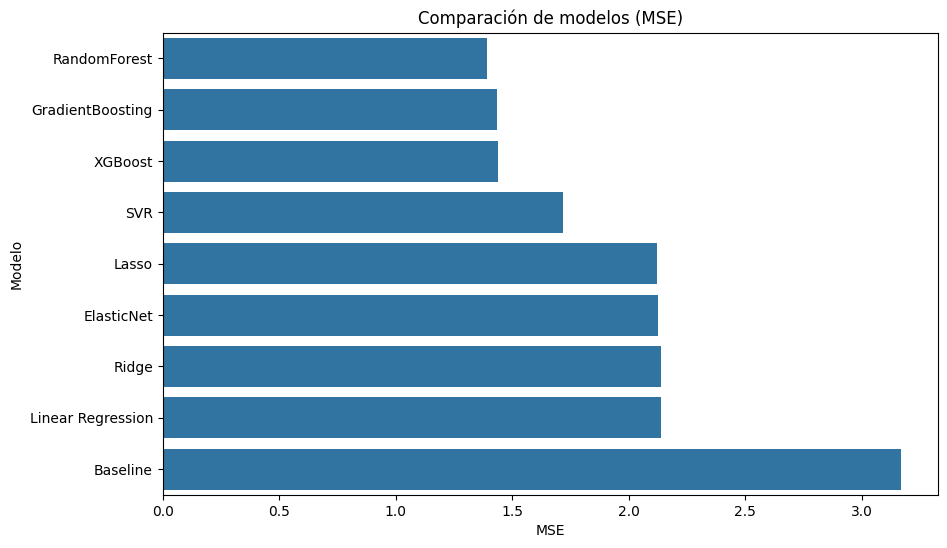

In [302]:
# Visualmente

plt.figure(figsize=(10, 6))

sns.barplot(
            data=results.sort_values(by='MSE',ascending=True),
            x='MSE',
            y='Modelo'
        )

plt.title('Comparación de modelos (MSE)')

plt.show()

# CONCLUSIONES:

Con un tratado de datos nulos a imputación de mediana:

* Mejores modelos MSE: RF, GBR, XGBoost
* Mejores modelos MSE(CV): GBR, XGBoost, SVR

Con lo cual, a partir de aquí, para el siguiente paso (imputación de nulos por vecinos cercanos), nos centraremos en estos 4: RF, GBR, XGBoost, SVR

# KNNImputer

Vamos a probar estos dos modelos con un dataset que en lugar de imputar la mediana a los nulos impute por vecinos cercanos

In [303]:
df.columns

Index(['V0', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'deseada',
       'V3_log'],
      dtype='object')

In [304]:
# desde df_original porque tenemos que aplicar a nulos antes de hacer el log v3
df_knn = df_original.copy()

In [305]:
df_knn.isna().sum()

V0          0
V1         71
V2         63
V3         68
V4          0
V5         63
V6         70
V7         60
V8         68
V9          0
deseada     0
dtype: int64

In [306]:
from sklearn.impute import KNNImputer

In [307]:
# para prueba rápida (ver si mejora MSE) usamos el valor estándar k = 5, luego haremos un rango y usaremos for i in ese rango (si de verdad mejora)
imputer_knn = KNNImputer(n_neighbors=5)

In [308]:
# lo metemos en un dateFrame porque el fit nos devuelve un array sin nombre de columnas
df_knn = pd.DataFrame(
                        imputer_knn.fit_transform(df_knn),
                        columns=df_knn.columns
                    )

In [309]:
# comprobamos que ya no hayan null
df_knn.isnull().sum()

V0         0
V1         0
V2         0
V3         0
V4         0
V5         0
V6         0
V7         0
V8         0
V9         0
deseada    0
dtype: int64

In [310]:
df_knn.describe().T

,count,mean,std,min,25%,50%,75%,max
V0,436.0,50.893945,48.915139,0.000000,17.070000,41.350000,74.570000,347.320000
V1,436.0,3.273769,1.719738,0.000000,2.865397,3.803535,4.370558,6.350802
V2,436.0,0.649371,0.744622,0.000000,0.000000,0.200000,1.029253,4.242641
V3,436.0,33.789621,59.111354,-2.948815,2.474174,13.833793,40.477891,765.558650
V4,436.0,0.045051,1.056036,-2.761062,-0.656870,0.068302,0.804713,2.562528
V5,436.0,2.517971,0.818481,1.000000,1.975000,2.344000,2.965250,6.439000
V6,436.0,1.029549,0.382991,0.281000,0.759550,1.000000,1.213250,2.500000
V7,436.0,1.067890,1.419009,0.000000,0.000000,1.000000,2.000000,11.000000
V8,436.0,0.380734,0.826679,0.000000,0.000000,0.000000,1.000000,11.000000
V9,436.0,0.470497,0.286910,0.000187,0.222742,0.458547,0.724238,0.997623


In [311]:
# procedemos a aplicar transformación log a v3
# para ello, desplamos todo a +1 ya que tiene min negativo (-2.94)
df_knn['V3_shift'] = (df_knn['V3'] - df_knn['V3'].min() + 1)

# aplicamos el log ahora que no tenemos negativos y lp1 para los números 0
df_knn['V3_log'] = np.log1p(df_knn['V3_shift'])

# limpiamos columnas "auxiliares"
df_knn = df_knn.drop(columns=['V3', 'V3_shift'])

In [312]:
df_knn.describe().T

,count,mean,std,min,25%,50%,75%,max
V0,436.0,50.893945,48.915139,0.000000,17.070000,41.350000,74.570000,347.320000
V1,436.0,3.273769,1.719738,0.000000,2.865397,3.803535,4.370558,6.350802
V2,436.0,0.649371,0.744622,0.000000,0.000000,0.200000,1.029253,4.242641
V4,436.0,0.045051,1.056036,-2.761062,-0.656870,0.068302,0.804713,2.562528
V5,436.0,2.517971,0.818481,1.000000,1.975000,2.344000,2.965250,6.439000
V6,436.0,1.029549,0.382991,0.281000,0.759550,1.000000,1.213250,2.500000
V7,436.0,1.067890,1.419009,0.000000,0.000000,1.000000,2.000000,11.000000
V8,436.0,0.380734,0.826679,0.000000,0.000000,0.000000,1.000000,11.000000
V9,436.0,0.470497,0.286910,0.000187,0.222742,0.458547,0.724238,0.997623
deseada,436.0,4.694101,1.662778,0.495000,3.627250,4.560000,5.600000,10.047000


### Split

In [313]:
X_knn = df_knn.drop(columns='deseada')

y_knn = df_knn['deseada']
X_train_knn, X_test_knn, y_train_knn, y_test_knn = train_test_split(
                                                                    X_knn,
                                                                    y_knn,
                                                                    test_size=0.2,
                                                                    random_state=42,
                                                                    shuffle=True
                                                                )

print(X_train_knn.shape,y_train_knn.shape)
print(X_test_knn.shape,y_test_knn.shape)

(348, 10) (348,)
(88, 10) (88,)


## RandomForest (knn)

In [314]:
# defino (igual que arriba para poder ser comparables los resultados)
rf_knn = RandomForestRegressor(
                                n_estimators=200,
                                max_depth=None,
                                random_state=42
                            )

# entreno
rf_knn.fit( X_train_knn, y_train_knn)

# predigo
y_pred_rf_knn = rf_knn.predict(X_test_knn)

In [315]:
mse_rf_knn = mean_squared_error( y_test_knn, y_pred_rf_knn)

print("RandomForest knn:", mse_rf_knn)

RandomForest knn: 1.2498989877562496


In [316]:
cv_scores_rf_knn = cross_val_score(
                                    rf_knn,
                                    X_train_knn,
                                    y_train_knn,
                                    cv=kf,
                                    scoring='neg_mean_squared_error',
                                    n_jobs=-1
                                )

cv_mse_rf_knn = -cv_scores_rf_knn.mean()

print("RandomForest knn (CV):", cv_mse_rf_knn)

RandomForest knn (CV): 1.4639331158948021


## Gradient Boosting (knn)

In [317]:
# defino (=gbr)
gbr_knn = GradientBoostingRegressor(
                                    n_estimators=200,
                                    learning_rate=0.05,
                                    max_depth=3,
                                    random_state=42
                                )

# entreno
gbr_knn.fit(X_train_knn, y_train_knn)

# predigo
y_pred_gbr_knn = gbr_knn.predict(X_test_knn)

In [318]:
mse_gbr_knn = mean_squared_error(y_test_knn, y_pred_gbr_knn)

print("GradientBoosting knn:", mse_gbr_knn)

GradientBoosting knn: 1.2251138734273377


In [319]:
cv_scores_gbr_knn = cross_val_score(
                                    gbr_knn,
                                    X_train_knn,
                                    y_train_knn,
                                    cv=kf,
                                    scoring='neg_mean_squared_error',
                                    n_jobs=-1
                                )

cv_mse_gbr_knn = -cv_scores_gbr_knn.mean()

print("GradientBoosting knn (CV):", cv_mse_gbr_knn)

GradientBoosting knn (CV): 1.4726327090494757


## XGBoost (knn)

In [320]:
# defino (de momento "a ojo" los hiperparámetros, como antes para que sea comparable)
xgb = XGBRegressor(
                    n_estimators=300,
                    learning_rate=0.05,
                    max_depth=3,
                    random_state=42
                )

# entreno
xgb.fit(X_train_knn, y_train_knn)

# predigo
y_pred_xgb_knn = xgb.predict(X_test_knn)

In [321]:
mse_xgb_knn = mean_squared_error(y_test_knn, y_pred_xgb_knn)

print("XGB knn MSE:", mse_xgb_knn)

XGB knn MSE: 1.3652739126993871


In [322]:
cv_scores_xgb_knn = cross_val_score(
                                    xgb,
                                    X_train_knn,
                                    y_train_knn,
                                    cv=kf,
                                    scoring='neg_mean_squared_error',
                                    n_jobs=-1
                                )

cv_mse_xgb_knn = -cv_scores_xgb_knn.mean()

print("XGB knn MSE (CV):", cv_mse_xgb_knn)

XGB knn MSE (CV): 1.4272738298661742


## SVR (knn)

In [323]:
# defino (lo mismo que arriba para que sean comparables)
pipe_svr_knn = Pipeline([
                            ('scaler', StandardScaler()),
                            ('model', SVR(
                                            kernel='rbf',
                                            C=1.0,
                                            epsilon=0.1
                                        )
                            )
                        ])

# entreno
pipe_svr_knn.fit(X_train_knn, y_train_knn)
#predigo
y_pred_svr_knn = pipe_svr_knn.predict(X_test_knn)

In [324]:
mse_svr_knn = mean_squared_error(y_test_knn,y_pred_svr_knn)

print("SVR knn:", mse_svr_knn)

SVR knn: 1.5094799802458134


In [325]:
cv_scores_svr_tuned_knn = cross_val_score(
                                            pipe_svr_knn,
                                            X_train_knn,
                                            y_train_knn,
                                            cv=kf,
                                            scoring='neg_mean_squared_error',
                                            n_jobs=-1
                                        )

cv_mse_svr_knn = -cv_scores_svr_tuned_knn.mean()

print("SVR knn (CV):", cv_mse_svr_knn)

SVR knn (CV): 1.490725438187573


In [326]:
# actualizo resultados

results_update_knn = pd.DataFrame({
                                    'Modelo': [
                                                'RandomForest knn',
                                                'GradientBoosting knn',
                                                'XGBoost knn',
                                                'SVR knn'
                                            ],
                                    
                                    'MSE': [
                                                    mse_rf_knn,
                                                    mse_gbr_knn,
                                                    mse_xgb_knn,
                                                    mse_svr_knn
                                                ],
                                    
                                    'MSE_CV': [
                                                cv_mse_rf_knn,
                                                cv_mse_gbr_knn,
                                                cv_mse_xgb_knn,
                                                cv_mse_svr_knn
                                            ]
                                })

# concateno
results = pd.concat(
                    [results, results_update_knn],
                    ignore_index=True
                )

In [327]:
results.sort_values(by='MSE_CV',ascending=True)

,Modelo,MSE,MSE_CV
11,XGBoost knn,1.365274,1.427274
9,RandomForest knn,1.249899,1.463933
10,GradientBoosting knn,1.225114,1.472633
12,SVR knn,1.509480,1.490725
0,GradientBoosting,1.434772,1.544250
1,XGBoost,1.440604,1.595137
2,SVR,1.718736,1.601990
3,RandomForest,1.393075,1.681636
4,Lasso,2.122271,1.818678
5,ElasticNet,2.127969,1.820991


In [328]:
results.sort_values(by='MSE',ascending=True)

,Modelo,MSE,MSE_CV
10,GradientBoosting knn,1.225114,1.472633
9,RandomForest knn,1.249899,1.463933
11,XGBoost knn,1.365274,1.427274
3,RandomForest,1.393075,1.681636
0,GradientBoosting,1.434772,1.544250
1,XGBoost,1.440604,1.595137
12,SVR knn,1.509480,1.490725
2,SVR,1.718736,1.601990
4,Lasso,2.122271,1.818678
5,ElasticNet,2.127969,1.820991


# CONCLUSIONES:

Cuando tratamos los nulos con imputación por vecios cercanos (k=5) el MSE de los modelos de estudio se reduce, 
Con lo que el siguiente paso de estudio o cambio son: los hiperparametros con el método GridSearchCV.

Modelos de estudio: XGB, RF, GBR.

## Features Importance

Breve break para saber qué variables explicativas son más importantes en cada modelo

In [329]:
importances_rf = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)

importances_rf

V3_log    0.284862
V5        0.165218
V6        0.137841
V0        0.113114
V9        0.084580
V1        0.075099
V4        0.069305
V2        0.030717
V7        0.027530
V8        0.011733
dtype: float64

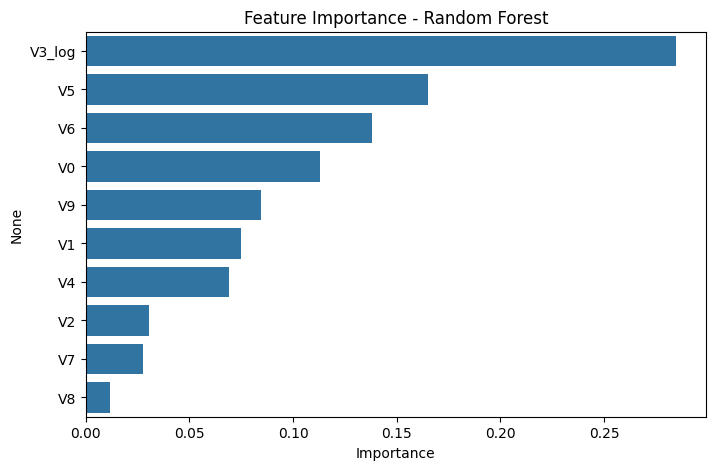

In [330]:
plt.figure(figsize=(8, 5))

sns.barplot(
            x=importances_rf.values,
            y=importances_rf.index
        )

plt.title('Feature Importance - Random Forest')

plt.xlabel('Importance')

plt.show()

In [331]:
importances_gbr = pd.Series(gbr.feature_importances_, index=X.columns).sort_values(ascending=False)

importances_gbr

V3_log    0.296422
V5        0.170277
V6        0.151640
V0        0.144248
V9        0.073224
V4        0.070572
V1        0.049424
V2        0.026883
V7        0.016332
V8        0.000978
dtype: float64

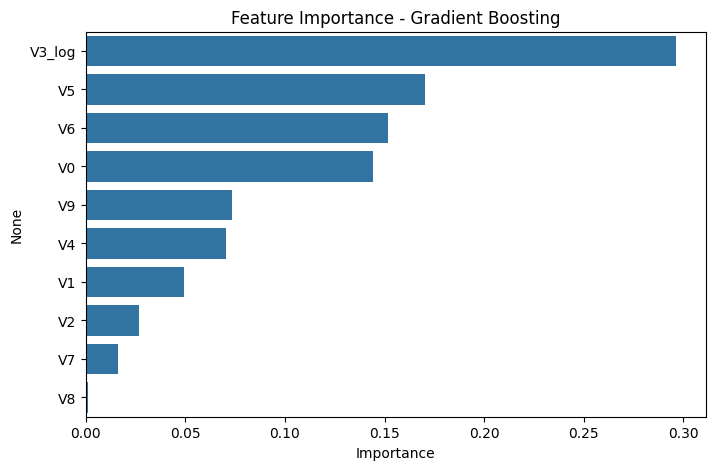

In [332]:
plt.figure(figsize=(8, 5))

sns.barplot(
            x=importances_gbr.values,
            y=importances_gbr.index
        )

plt.title('Feature Importance - Gradient Boosting')

plt.xlabel('Importance')

plt.show()

In [333]:
importances_xgb = pd.Series(xgb.feature_importances_, index=X.columns).sort_values(ascending=False)

importances_xgb

V3_log    0.213476
V2        0.180394
V5        0.148666
V8        0.085401
V6        0.085370
V0        0.080787
V1        0.065378
V7        0.048400
V9        0.046758
V4        0.045369
dtype: float32

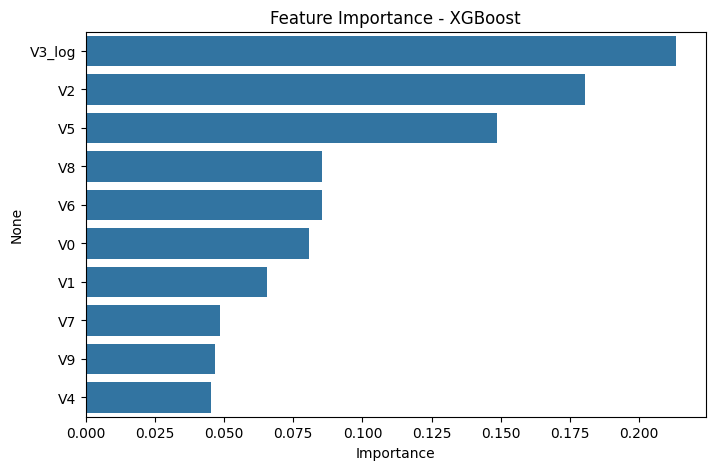

In [334]:
plt.figure(figsize=(8, 5))

sns.barplot(
            x=importances_xgb.values,
            y=importances_xgb.index
        )

plt.title('Feature Importance - XGBoost')

plt.xlabel('Importance')

plt.show()

# CONCLUSIONES:

RF y GBR tienen prácticamente el mismo orden de importancia en las variables explicativas (top 5 igual)
XGB cambia

# GridSearchCV

Como en el estudio presentado, no estudié XGB, ahora mismo lo expcluimos en la exposición:


* RF:
    - n_estimators
    - max_depth
    - min_samples_split
    - min_samples_leaf
    - max_features

* GBR: 
    - n_estimators
    - learning_rate
    - max_depth
    - min_samples_split
    - min_samples_leaf
    - subsample

In [335]:
from sklearn.model_selection import GridSearchCV

## Random Forest (mejores hiperparámetros)

In [336]:
# Parametrizamos para obtener los parametros con mejor MSE
rf_base = RandomForestRegressor(
                                random_state=42,
                                n_jobs=-1
                            )

param_dist_rf = {
                    'n_estimators': [100, 200, 300, 500],
                    'max_depth': [None, 4, 5, 6, 7, 8, 10, 12],
                    'min_samples_split': [2, 4, 6, 8, 10],
                    'min_samples_leaf': [1, 2, 3, 4, 5],
                    'max_features': ['sqrt', 'log2', None]
                }

In [337]:
# definimos modelo con los hiperparametros parametrizados
random_rf = RandomizedSearchCV(
                                estimator=rf_base,
                                param_distributions=param_dist_rf,
                                n_iter=50, # lo estándar
                                cv=kf, # cv = 5 pero con shuffle (cv =5 es lo estándar, lo hemos hecho con KFold)
                                scoring='neg_mean_squared_error',
                                random_state=42,
                                n_jobs=-1
                            )

# entrenamos
random_rf.fit(X_train_knn, y_train_knn)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestR...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'max_depth': [None, 4, ...], 'max_features': ['sqrt', 'log2', ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 4, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",50
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'neg_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategie

In [341]:
# mejores parámetros parametrizados
random_rf.best_params_

cv_mse_rf_knn_best = -random_rf.best_score_

print("RF GS MSE (CV):", cv_mse_rf_knn_best)

RF GS MSE (CV): 1.4024235506435823


In [343]:
# predecimos
best_rf = random_rf.best_estimator_
y_pred_rf_knn_best = best_rf.predict(X_test_knn)


In [344]:

# MSE del modelo 
mse_rf_knn_best = mean_squared_error(y_test_knn, y_pred_rf_knn_best)

print("RF Test MSE:", mse_rf_knn_best)

RF Test MSE: 1.391739906251426


In [345]:
print("RF mejores parámetros:", random_rf.best_params_)

RF mejores parámetros: {'n_estimators': 500, 'min_samples_split': 4, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 10}


## Gradient Boosting (mejores hiperparámetros)

In [346]:
# Parametrizamos para obtener los parámetros con mejor MSE
gbr_base = GradientBoostingRegressor(random_state=42)

param_dist_gbr = {
                    'n_estimators': [100, 200, 300, 500],
                    'learning_rate': [0.01, 0.03, 0.05, 0.1],
                    'max_depth': [2, 3, 4, 5],
                    'min_samples_split': [2, 4, 6, 8, 10],
                    'min_samples_leaf': [1, 2, 3, 4, 5],
                    'subsample': [0.7, 0.8, 0.9, 1.0]
                }

In [348]:
# Definimos modelo con los hiperparámetros parametrizados
random_gbr = RandomizedSearchCV(
                                estimator=gbr_base,
                                param_distributions=param_dist_gbr,
                                n_iter=50,
                                cv=kf,
                                scoring='neg_mean_squared_error',
                                random_state=42,
                                n_jobs=-1
                            )

# entrenamos
random_gbr.fit(X_train_knn, y_train_knn)

# Mejor MSE en CV
cv_mse_gbr_knn_best = -random_gbr.best_score_

print("GBR best MSE(CV):", cv_mse_gbr_knn_best)
print("GBR mejores parámetros:", random_gbr.best_params_)

GBR best MSE(CV): 1.3689264993912116
GBR mejores parámetros: {'subsample': 0.7, 'n_estimators': 200, 'min_samples_split': 6, 'min_samples_leaf': 5, 'max_depth': 2, 'learning_rate': 0.05}


In [349]:

# Modelo con mejores hiperparámetros
best_gbr = random_gbr.best_estimator_

# MSE en test
y_pred_gbr_knn_best = best_gbr.predict(X_test_knn)

mse_gbr_knn_best = mean_squared_error(y_test_knn, y_pred_gbr_knn_best)

print("GBR best MSE:", mse_gbr_knn_best)

GBR best MSE: 1.1739763539425914


In [350]:
# actualizo resultados

results_update_best = pd.DataFrame({
                                    'Modelo': [
                                                'RandomForest knn best',
                                                'GradientBoosting knn best'
                                            ],
                                    
                                    'MSE': [
                                                    mse_rf_knn_best,
                                                    mse_gbr_knn_best
                                                ],
                                    
                                    'MSE_CV': [
                                                cv_mse_rf_knn_best,
                                                cv_mse_gbr_knn_best
                                            ]
                                })

# concateno
results = pd.concat(
                    [results, results_update_best],
                    ignore_index=True
                )

In [351]:
results.sort_values(by='MSE_CV',ascending=True)

,Modelo,MSE,MSE_CV
14,GradientBoosting knn best,1.173976,1.368926
13,RandomForest knn best,1.391740,1.402424
11,XGBoost knn,1.365274,1.427274
9,RandomForest knn,1.249899,1.463933
10,GradientBoosting knn,1.225114,1.472633
12,SVR knn,1.509480,1.490725
0,GradientBoosting,1.434772,1.544250
1,XGBoost,1.440604,1.595137
2,SVR,1.718736,1.601990
3,RandomForest,1.393075,1.681636


In [352]:
results.sort_values(by='MSE',ascending=True)

,Modelo,MSE,MSE_CV
14,GradientBoosting knn best,1.173976,1.368926
10,GradientBoosting knn,1.225114,1.472633
9,RandomForest knn,1.249899,1.463933
11,XGBoost knn,1.365274,1.427274
13,RandomForest knn best,1.391740,1.402424
3,RandomForest,1.393075,1.681636
0,GradientBoosting,1.434772,1.544250
1,XGBoost,1.440604,1.595137
12,SVR knn,1.509480,1.490725
2,SVR,1.718736,1.601990


# CONCLUSIÓN

Tanto MSE como MSE_CV el mínimo está en el calculado con:

- Imputación de nulos con vecinos cercanos (k=5)
- Hiperparametrización de GBR

Como hemos visto en las features importances -> V8 es practicamente = 0  de importancia. Se puede eliminar.

Comparación predicciones RF con GBR 

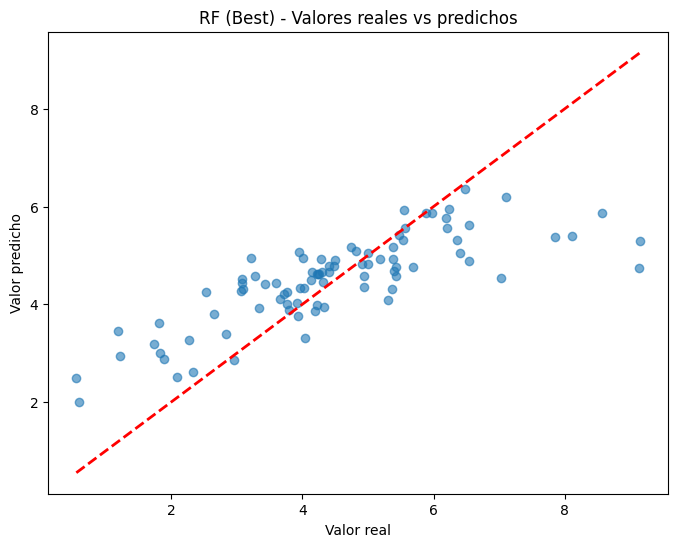

In [356]:
# Scatter
plt.figure(figsize=(8,6))
plt.scatter(y_test_knn, y_pred_rf_knn_best, alpha=0.6)

# Línea ideal
lims = [
    min(y_test_knn.min(), y_pred_rf_knn_best.min()),
    max(y_test_knn.max(), y_pred_rf_knn_best.max())
]

plt.plot(lims, lims, 'r--', linewidth=2)

plt.xlabel('Valor real')
plt.ylabel('Valor predicho')
plt.title('RF (Best) - Valores reales vs predichos')

plt.show()

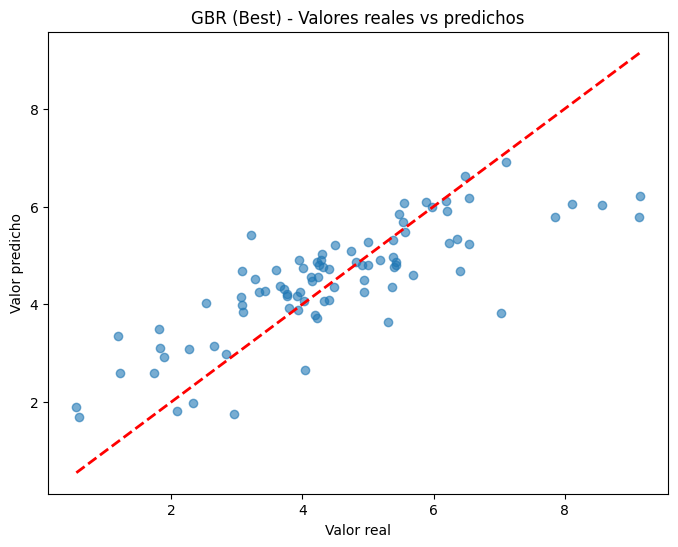

In [354]:
# Scatter
plt.figure(figsize=(8,6))
plt.scatter(y_test_knn, y_pred_gbr_knn_best, alpha=0.6)

# Línea ideal
lims = [
    min(y_test_knn.min(), y_pred_gbr_knn_best.min()),
    max(y_test_knn.max(), y_pred_gbr_knn_best.max())
]

plt.plot(lims, lims, 'r--', linewidth=2)

plt.xlabel('Valor real')
plt.ylabel('Valor predicho')
plt.title('GBR (Best) - Valores reales vs predichos')

plt.show()

# ELECCIÓN

- Dataset con imputación de nulos con vecinos cercanos (k=5) -> ver si hay otra k que lo minimice?
- Eliminación de V8 
- Aplicación de V3_log (y sutitución de V3 en su lugar) -> ojo porque tiene valores negativos 

In [358]:
## 1. Eliminamos V8

X_knn_no_v8 = X_knn.drop(columns=['V8'])

In [359]:
X_train_no_v8, X_test_no_v8, y_train_no_v8, y_test_no_v8 = train_test_split(
                                                                            X_knn_no_v8,
                                                                            y_knn,
                                                                            test_size=0.2,
                                                                            random_state=42,
                                                                            shuffle=True
                                                                        )

In [361]:
from sklearn.base import clone

In [362]:
# defino
best_gbr_no_v8 = clone(random_gbr.best_estimator_)

# entreno
best_gbr_no_v8.fit(X_train_no_v8, y_train_no_v8)

# predigo 
y_pred_best_gbr_no_v8 = best_gbr_no_v8.predict(X_test_no_v8)

In [363]:
mse_best_gbr_no_v8 = mean_squared_error(y_test_no_v8, y_pred_best_gbr_no_v8)


In [364]:

cv_scores = cross_val_score(
                            best_gbr_no_v8,
                            X_train_no_v8,
                            y_train_no_v8,
                            cv=kf,
                            scoring='neg_mean_squared_error',
                            n_jobs=-1
                        )

cv_mse_best_gbr_no_v8 = -cv_scores.mean()                                     

In [365]:
# actualizo resultados

results_update_no_V8 = pd.DataFrame({
                                    'Modelo': [
                                                'GradientBoosting knn best noV8'
                                            ],
                                    
                                    'MSE': [
                                                mse_best_gbr_no_v8
                                            ],
                                    
                                    'MSE_CV': [
                                                cv_mse_best_gbr_no_v8
                                            ]
                                })

# concateno
results = pd.concat(
                    [results, results_update_no_V8],
                    ignore_index=True
                )

In [367]:
results = results.sort_values(by='MSE_CV',ascending=True)
results

,Modelo,MSE,MSE_CV
14,GradientBoosting knn best,1.173976,1.368926
15,GradientBoosting knn best noV8,1.189839,1.371697
13,RandomForest knn best,1.391740,1.402424
11,XGBoost knn,1.365274,1.427274
9,RandomForest knn,1.249899,1.463933
10,GradientBoosting knn,1.225114,1.472633
12,SVR knn,1.509480,1.490725
0,GradientBoosting,1.434772,1.544250
1,XGBoost,1.440604,1.595137
2,SVR,1.718736,1.601990


Curiosamente, hacer drop V8 y buscar mejores parametros, da mismo resultado que con mejores parametros todas las variables y pasarle dataset sin V8. Ahora mismo la decisión sería mantenerla pero en el entregado, la quité.

# Por último, podríamos ver que nº de vecinos (k) es el que minimiza el MSE para GBR optimizado (best hiperparametros)

Para evitar problema de dataLake tenemos que usar la siguiente función:

In [372]:
from sklearn.base import BaseEstimator, TransformerMixin

In [373]:
class V3LogTransformer(BaseEstimator, TransformerMixin):
    
    def __init__(self, feature_names):
        self.feature_names = feature_names
        
    def fit(self, X, y=None):
        X_df = pd.DataFrame(X, columns=self.feature_names)
        self.v3_min_ = X_df['V3'].min()
        return self
    
    def transform(self, X):
        X_df = pd.DataFrame(X, columns=self.feature_names).copy()
        
        X_df['V3_shift'] = X_df['V3'] - self.v3_min_ + 1
        X_df['V3_log'] = np.log1p(X_df['V3_shift'])
        
        X_df = X_df.drop(columns=['V3', 'V3_shift'])
        
        return X_df

In [374]:
X_raw = df_original.drop(columns='deseada').copy()
y_raw = df_original['deseada'].copy()

In [375]:
X_train, X_test, y_train, y_test = train_test_split(
                                                    X_raw,
                                                    y_raw,
                                                    test_size=0.2,
                                                    random_state=42,
                                                    shuffle=True
                                                )

In [378]:
best_gbr = GradientBoostingRegressor( **random_gbr.best_params_, random_state=42)

k_results_gbr = []

for k in [3, 5, 7, 9, 11]:

    pipe_gbr_k = Pipeline([
                            ('imputer', KNNImputer(n_neighbors=k)),
                            ('v3log', V3LogTransformer(feature_names=X_raw.columns)),
                            ('model', clone(best_gbr))
                        ])

    # Entrenamiento en train
    pipe_gbr_k.fit(X_train, y_train)

    # Predicción en test
    y_pred = pipe_gbr_k.predict(X_test)

    # MSE
    mse = mean_squared_error(y_test, y_pred)

    # MSE_CV 
    cv_scores = cross_val_score(
                                pipe_gbr_k,
                                X_train,
                                y_train,
                                cv=kf,
                                scoring='neg_mean_squared_error',
                                n_jobs=-1
                            )

    mse_cv = -cv_scores.mean()

    k_results_gbr.append([k, mse, mse_cv])

    print(
        f"k={k} --> MSE={mse:.4f} | MSE_CV={mse_cv:.4f}"
    )


k=3 --> MSE=1.3471 | MSE_CV=1.4880
k=5 --> MSE=1.2218 | MSE_CV=1.4719
k=7 --> MSE=1.3454 | MSE_CV=1.5283
k=9 --> MSE=1.3649 | MSE_CV=1.4902
k=11 --> MSE=1.3253 | MSE_CV=1.4921


In [380]:

k_results_gbr = pd.DataFrame(
                            k_results_gbr,
                            columns=['k', 'MSE', 'MSE_CV']
                        ).sort_values(by='MSE_CV', ascending=True)

k_results_gbr

,k,MSE,MSE_CV
1,5,1.221769,1.471850
0,3,1.347055,1.487983
3,9,1.364938,1.490225
4,11,1.325296,1.492115
2,7,1.345440,1.528327


In [382]:
k_results_gbr.sort_values(by='MSE', ascending=True)

,k,MSE,MSE_CV
1,5,1.221769,1.471850
4,11,1.325296,1.492115
2,7,1.345440,1.528327
0,3,1.347055,1.487983
3,9,1.364938,1.490225


# CONCLUSIÓN k óptimo (el que minimiza MSE y MSE_CV)

Coindice que el k óptimo (min MSE y MSE_CV) es k=5

# ELECCIÓN de MODELO y guardado

Tras el estudio, concluimos que, el modelo, con el tratamiento de nulos e hiperparámetros que minimiza el MSE es el siguiente:

- Dataset:
    * Imputación de KNNImputer k=5 para los nulos
    * Transformación, y sustitución, del logaritmo en V3
    * [Eliminación de V8 - opcional, yo no lo haré]

- Modelo: 
    * GBR con hipérparametros:
        - 'subsample': 0.7,
        - 'n_estimators': 200,
        - 'min_samples_split': 6,
        - 'min_samples_leaf': 5,
        - 'max_depth': 2,
        - 'learning_rate': 0.05,


In [ ]:
# ENTRENAMIENTO FINAL Y GUARDADO DEL PIPELINE

# Guardamos el pipeline completo:
# - KNNImputer(k=5)
# - Transformación logarítmica de V3
# - Gradient Boosting Regressor con los mejores hiperparámetros

pipeline_final = Pipeline([
                            ('imputer', KNNImputer(n_neighbors=5)),
                            ('v3log', V3LogTransformer(feature_names=X_raw.columns)),
                            ('model', clone(best_gbr))
                        ])

# Entrenamos utilizando TODO el conjunto de entrenamiento
pipeline_final.fit(X_raw, y_raw)


# Guardamos el pipeline para usar
joblib.dump(pipeline_final, "gbr_final_pipeline.pkl")

print("Pipeline guardado correctamente.")

Pipeline guardado correctamente.
